# **🚀 JAX / Flax NNX NanoUNet Diffusion model with Google Grain**

### ***From a mathematical concept to MLIR and StableHLO and Hugging Face Hub***

In this tutorial, we will abandon legacy frameworks and build a next-generation diffusion model. We will use **JAX** for lightning-fast compilation and **Flax NNX**, a modern interface that takes the purity of PyTorch (object-based layer notation) but retains the full functional power of JAX and the XLA compiler under the hood.

## ***1. Theoretical Introduction & Architecture***

### **1.1 Forward Process (Noise Addition)**
In a classic DDPM (Denoising Diffusion Probabilistic Model), a clean image $x_0$ is gradually degraded by adding Gaussian noise over hundreds of discrete time steps $T$ according to a non-linear variance schedule ($\beta_t$). This process requires tracking cumulative coefficients ($\bar{\alpha}_t$), which introduces unnecessary mathematical overhead for educational purposes.

In our simplified **"Toy" model**, we replace this discrete process with a continuous linear interpolation between the clean image and uniform noise over the interval $t \in [0, 1]$:

$$q(x_t \mid x_0) = (1 - t) \cdot x_0 + t \cdot \epsilon$$

where $\epsilon \sim \mathcal{U}(0, 1)$ represents the generated noise and $t$ (represented as `amount` in the code) determines the noise intensity:
* $t = 0$: Completely clean image ($x_0$).
* $t = 1$: Pure, structurally unreadable noise ($\epsilon$).

This approach perfectly preserves the core intuition of diffusion models—the neural network must learn to reconstruct data from any arbitrary level of destruction.

### **1.2 Reverse Process (Denoising & Generation)**
The goal of the reverse process is to take a random noise tensor and iteratively subtract the corruption until a new, clean sample emerges. While advanced generative models typically predict the added noise vector itself (noise prediction), our `RealNanoUNet` model is trained for **direct clean image prediction** ($\hat{x}_0$) from its noisy version $x_t$, conditioned on the current noise level $t$:

$$\hat{x}_0 = f_\theta(x_t, t)$$

Training is performed by minimizing the Mean Squared Error (MSE) between the ground-truth clean image and the network's prediction:

$$\mathcal{L} = \mathbb{E}_{x_0, t, \epsilon} \left[ \| f_\theta(x_t, t) - x_0 \|^2 \right]$$

During sampling (generation), we start with pure random noise $x_1$ and descend towards $t=0$ in $N$ discrete steps (e.g., 10 steps). At each step, the model estimates the final clean image $\hat{x}_0$. To simulate the progressive refinement typical of diffusion processes, we slightly re-noise this prediction back to a slightly lower noise level $t_{next}$, repeating this cycle until we reach the final clean output.

### **1.3 Architecture: Conditional RealNanoUNet**
To know how aggressively to "repair" the image, the network cannot look at the noisy input $x_t$ alone. It must be explicitly conditioned on the noise level $t$.
1. **Sinusoidal Positional Embedding:** The scalar value $t$ is mapped into a high-dimensional feature vector (embedding) using harmonic functions (sine and cosine waves) across various frequencies. This enables the network to perceive subtle differences in noise levels with high numerical sensitivity.
2. **U-Net with Time Conditioning:** The time/noise embedding is projected via MLP layers and added (using broadcasting) to the feature maps at every stage of the network. The architecture utilizes:
   * **Downsampling:** A strided convolution reduces the spatial resolution ($28 \times 28 \rightarrow 14 \times 14$) to capture global spatial context.
   * **Upsampling:** A transposed convolution (ConvTranspose) reconstructs the original resolution back to $28 \times 28$.
   * **Skip Connection (Residual Shortcut):** Features from the initial layer are directly added to the features right before the final output. This prevents the loss of fine structural details (edges) and significantly stabilizes the training dynamics.

### **1.4 Technological Stack & Multi-Format Export**
This tutorial demonstrates a cutting-edge production pipeline built entirely on the modern Google ecosystem:
* **JAX & XLA:** Computation graphs are not executed interpretively as in standard Python. JAX compiles the entire graphics pipeline via XLA (Accelerated Linear Algebra) into highly optimized machine code targeted directly at the GPU.
* **Flax NNX:** The next-generation interface for the Flax library. It abandons the complex functional state management of legacy `Flax Linen` in favor of a clean, object-oriented approach (highly intuitive and similar to PyTorch), while fully retaining JAX transformations (`@nnx.jit`, `nnx.value_and_grad`).
* **Google Grain:** A high-performance, deterministic, and pure-Python data loader. It is designed specifically to integrate seamlessly with JAX pipelines, eliminating the memory leaks and multi-threading bottlenecks that often plague legacy data loading solutions.
* **AOT & Multi-Format Export:** After training, the model is completely decoupled from Python. Using `jax.export`, we generate **MLIR** (Multi-Level Intermediate Representation) and a universal **StableHLO** bytecode.

In [1]:
%pip uninstall -y jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt gym gymnax dopamine-rl kaggle-environments
%pip install -qqq --upgrade "jax[cuda12_local]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
%pip install -qqq jax-cuda12-plugin jax-cuda12-pjrt 
%pip install -qqq -U diffusers datasets transformers accelerate ftfy pyarrow
%pip install "jax-lnn[gpu,export]"
%pip install -qqq flax optax orbax-checkpoint huggingface_hub matplotlib torch torchvision jax2onnx onnx onnxruntime
%pip install -qqq grain gym gymnax dopamine-rl kaggle-environments
%pip install -qqq graphviz

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: jax-cuda12-plugin 0.7.2
Uninstalling jax-cuda12-plugin-0.7.2:
  Successfully uninstalled jax-cuda12-plugin-0.7.2
Found existing installation: jax-cuda12-pjrt 0.7.2
Uninstalling jax-cuda12-pjrt-0.7.2:
  Successfully uninstalled jax-cuda12-pjrt-0.7.2
Found existing installation: gym 0.26.2
Uninstalling gym-0.26.2:
  Successfully uninstalled gym-0.26.2
Found existing installation: gymnax 0.0.8
Uninstalling gymnax-0.0.8:
  Successfully uninstalled gymnax-0.0.8
Found existing installation: dopamine_rl 4.1.2
Uninstalling dopamine_rl-4.1.2:
  Successfully uninstalled dopamine_rl-4.1.2
Found existing installation: kaggle-environments 1.29.3
Uninstalling kaggle-environments-1.29.3:
  Successfully uninstalled kaggle-environments-1.29.3
Note: you may need to rest

In [2]:
%pip show flax

Name: flax
Version: 0.12.7
Summary: Flax: A neural network library for JAX designed for flexibility
Home-page: https://github.com/google/flax
Author: 
Author-email: Flax team <flax-dev@google.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: jax, msgpack, numpy, optax, orbax-checkpoint, PyYAML, rich, tensorstore, treescope, typing_extensions
Required-by: dopamine_rl, gymnax, jax-lnn, jax2onnx
Note: you may need to restart the kernel to use updated packages.


In [3]:
import jax
print("JAX version:", jax.__version__)
print("Device:", jax.devices())

JAX version: 0.10.2
Device: [CudaDevice(id=0), CudaDevice(id=1)]


In [4]:
!apt install git-lfs

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 124 not upgraded.


## ***Imports***

In [5]:
import os
import shutil
import glob
import subprocess
import gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import torch
import torchvision


import jax
import jax.numpy as jnp
from flax import nnx
import optax
import orbax.checkpoint as ocp
import jax.export as jax_export
from jlnn.export.stablehlo import export_to_stablehlo, save_stablehlo_artifact

from huggingface_hub import HfApi, ModelCard, ModelCardData
from huggingface_hub import login as hf_login

from kaggle_secrets import UserSecretsClient

import grain.python as grain


In [6]:
print(f"JAX detected these devices: {jax.devices()}")

JAX detected these devices: [CudaDevice(id=0), CudaDevice(id=1)]


------------------------------------
## ***Git settings***
------------------------------------

In [7]:
def set_git_config(email, name):
    try:
        # Setting global user.email
        subprocess.run(["git", "config", "--global", "user.email", email], check=True)

        # Setting the global user.name
        subprocess.run(["git", "config", "--global", "user.name", name], check=True)
        
        # Check settings (optional)
        email_output = subprocess.run(["git", "config", "--global", "user.email"], capture_output=True, text=True, check=True)
        name_output = subprocess.run(["git", "config", "--global", "user.name"], capture_output=True, text=True, check=True)

    except subprocess.CalledProcessError as e:
        print(f"Error while setting up Git configuration: {e}")

In [8]:
try:
    user_secrets = UserSecretsClient()
    
    hf_token = user_secrets.get_secret("HF_TOKEN")
    user_email = user_secrets.get_secret("user_email")
    user_name = user_secrets.get_secret("user_name")
except Exception:
    pass

In [9]:
set_git_config(user_email, user_name)

----------------------------------------------------
## ***Global settings for debugging***
----------------------------------------------------

In [10]:
DEBUG = False  # SWITCH TO FALSE FOR A SHARP TRAINING
BATCH_SIZE = 8 if DEBUG else 128

# 🐛 Hard cap on how many batches the training loop runs through in DEBUG mode.
# This is what actually makes debugging fast - with 1200 debug samples / batch_size 8
# you'd otherwise still churn through 150 batches every 'epoch'.
DEBUG_MAX_BATCHES = None  # set to None to run through the whole debug dataset

----------------------------------------------------
## ***2. DATA PREPARATION (Google Grain & MNIST)***
----------------------------------------------------

In [11]:
def normalize_and_format_fn(element):
    """Native transform function for image normalization [0, 1]."""
    # element is a pair (image, label)
    image, _ = element
    return image.astype(np.float32) / 255.0

In [12]:
def get_grain_mnist_dataset(batch_size=64, debug_mode=False):
    """Instantly loads MNIST via torchvision and trims it to exactly the desired pattern."""
    
    # 1. Downloading purely via PyTorch (a matter of one second)
    torch_train = torchvision.datasets.MNIST(root='./data', train=True, download=True)
    torch_test = torchvision.datasets.MNIST(root='./data', train=False, download=True)
    
    # 2. Extracting raw NumPy arrays from PyTorch tensors
    train_images = torch_train.data.numpy()
    train_labels = torch_train.targets.numpy()
    test_images = torch_test.data.numpy()
    test_labels = torch_test.targets.numpy()
    
    # Add a channel to the end (H, W) -> (H, W, 1) as required by our CNN
    train_images = np.expand_dims(train_images, axis=-1)
    test_images = np.expand_dims(test_images, axis=-1)
    
    # 3. 🔥 PRECISE debug slice: 1200 samples (2% of 60k) and 200 samples (2% of 10k)
    if debug_mode:
        print(f"🔬 DEBUG ACTIVE: I take exactly 1200 training and 200 test samples (2%).")
        train_data = [(train_images[i], train_labels[i]) for i in range(1200)]
        test_data = [(test_images[i], test_labels[i]) for i in range(200)]
    else:
        print(f"🚀 SHARP RUN: Loading full dataset ({len(train_images)} samples).")
        train_data = [(train_images[i], train_labels[i]) for i in range(len(train_images))]
        test_data = [(test_images[i], test_labels[i]) for i in range(len(test_images))]
        
    # 4. Creating a Google Grain MapDataset directly from a Python list of pairs
    dataset = grain.MapDataset.source(train_data)
    
    sampler = grain.IndexSampler(
        num_records=len(train_data),
        shuffle=True,
        seed=42,
        shard_options=grain.NoSharding()
    )
    
    # 5. Applying Grain transformations (your original function is called)
    dataset = dataset.map(normalize_and_format_fn)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    
    loader = grain.DataLoader(
        data_source=dataset,
        sampler=sampler,
        worker_count=0
    )
    
    return loader

#### Testing the modified loader

In [13]:
train_loader = get_grain_mnist_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG)
batch_img = next(iter(train_loader))
print(f"🤖 [DEBUG={DEBUG}] Test batch shape:", batch_img.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]

🔬 DEBUG ACTIVE: I take exactly 1200 training and 200 test samples (2%).
🤖 [DEBUG=True] Test batch shape: (8, 28, 28, 1)


----------------------------------------------------
## ***3. CORRUPTION PROCESS (Adding noise in JAX)***
----------------------------------------------------

In [14]:
def corrupt_jax(rng, x, amount):
    """Linearly blends an image with uniform noise based on the amount parameter."""
    noise = jax.random.uniform(rng, shape=x.shape)
    amount = amount.reshape(-1, 1, 1, 1)
    return x * (1.0 - amount) + noise * amount

--------------------------------------------------------------------
## ***4. REAL ARCHITECTURE: REAL NanoUNet WITH NOISE CONDITIONING***
--------------------------------------------------------------------

In [15]:
def sinusoidal_embedding(amounts, embedding_dim=32):
    """Transforms scalar noise levels into positional sinusoidal embeddings."""
    half_dim = embedding_dim // 2
    # Creating an exponential frequency range
    emb = jnp.log(10000.0) / (half_dim - 1)
    emb = jnp.exp(jnp.arange(half_dim, dtype=jnp.float32) * -emb)
    # Multiply by noise level
    emb = amounts[:, None] * emb[None, :]
    # Combining sines and cosines into one vector
    emb = jnp.concatenate([jnp.sin(emb), jnp.cos(emb)], axis=-1)
    return emb

In [16]:
class RealNanoUNet(nnx.Module):
    """A real, conditional NanoUNet with time nesting, down/up sampling, and skip connections."""
    def __init__(self, in_features: int, out_features: int, rngs: nnx.Rngs):
        super().__init__()
        emb_dim = 32
        
        # MLPs for processing time/noise embedding
        self.time_mlp1 = nnx.Linear(emb_dim, 16, rngs=rngs)
        self.time_mlp2 = nnx.Linear(emb_dim, 32, rngs=rngs)
        self.time_mlp3 = nnx.Linear(emb_dim, 16, rngs=rngs)
        
        # Descending path (Downsampling via strided convolution)
        self.down1 = nnx.Conv(in_features, 16, kernel_size=(3, 3), padding="SAME", rngs=rngs)
        self.down2 = nnx.Conv(16, 32, kernel_size=(3, 3), strides=(2, 2), padding="SAME", rngs=rngs) # 28x28 -> 14x14
        
        # Upsampling via transposed convolutions
        self.up1 = nnx.ConvTranspose(32, 16, kernel_size=(3, 3), strides=(2, 2), padding="SAME", rngs=rngs) # 14x14 -> 28x28
        self.up2 = nnx.Conv(16, out_features, kernel_size=(3, 3), padding="SAME", rngs=rngs)
        
    def __call__(self, x, amounts):
        # 1. Noise embedding calculation and projection
        t_emb = sinusoidal_embedding(amounts, embedding_dim=32)
        t_proj1 = self.time_mlp1(t_emb)[:, None, None, :] # Shape (B, 1, 1, 16) for broadcasting
        t_proj2 = self.time_mlp2(t_emb)[:, None, None, :] # Shape (B, 1, 1, 32)
        t_proj3 = self.time_mlp3(t_emb)[:, None, None, :] # Shape (B, 1, 1, 16)
        
        # 2. Descending Passage
        h1 = jax.nn.silu(self.down1(x) + t_proj1)         # Dimension: 28x28x16
        h2 = jax.nn.silu(self.down2(h1) + t_proj2)        # Dimension: 14x14x32
        
        # 3. Upward Passage with Shortcut Connection (Skip Connection)
        h3 = jax.nn.silu(self.up1(h2) + t_proj3)          # Dimension: 28x28x16
        h4 = h3 + h1                                      # Real UNet residual abbreviation from h1 layer
        
        out = self.up2(h4)                                # Exit: 28x28x1
        return out

#### ***Initialize the real model***

In [17]:
model_rngs = nnx.Rngs(42)
model = RealNanoUNet(in_features=1, out_features=1, rngs=model_rngs)

#### ***Forward pass verification with noise floor pass***

In [18]:
vzorove_amounts = jnp.array([0.5] * batch_img.shape[0], dtype=jnp.float32)
y_test_pred = model(batch_img, vzorove_amounts)
print("The shape of NanoUNet's real conditional prediction:", y_test_pred.shape)

The shape of NanoUNet's real conditional prediction: (8, 28, 28, 1)


----------------------------------------------------------
## ***5. ASYNCHRONOUS FILE LOG (KAGGLE SAFE)***
----------------------------------------------------------

#### Setting up the logging mechanism

In [19]:
log_filename = "/kaggle/working/training_diffusion.log"

#### Reset any old loggers so that the file is not overwritten wildly when the cell is restarted

In [20]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

In [21]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_filename, mode="w", encoding="utf-8"),
        # We will also keep the stream to the console, but suppress the logger so as not to overload Kaggle
    ]
)

----------------------------------------------------------
## ***6. OPTIMIZATION, TRAINING AND ORBAX CHECKPOINTING***
----------------------------------------------------------

#### Parameters for the learning scheduler
#### Dynamic settings depending on whether we are tuning or training live

In [22]:
NUM_EPOCHS = 1 if DEBUG else 80
LOG_EVERY_N_BATCHES = 1 if DEBUG else 50

warmup_steps = 100
total_steps = 1000

In [23]:
print(f"⚙️ Configuration: DEBUG={DEBUG} | Epochs={NUM_EPOCHS} | Logging every {LOG_EVERY_N_BATCHES} batches")

⚙️ Configuration: DEBUG=True | Epochs=1 | Logging every 1 batches


In [24]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-6
)

#### Robust NNX Optimizer with explicit wrt=nnx.Param

In [25]:
optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(lr_schedule, weight_decay=0.1)
    ),
    wrt=nnx.Param
)

In [26]:
@nnx.jit
def train_step(model, optimizer, batch, step_rng):
    """Training step fully compatible with Flax >= 0.11.0 API."""
    rng1, rng2 = jax.random.split(step_rng)
    
    noise_amount = jax.random.uniform(rng1, shape=(batch.shape[0],))
    noisy_inputs = corrupt_jax(rng2, batch, noise_amount)
    
    def loss_fn(model):
        pred = model(noisy_inputs, noise_amount)
        return jnp.mean((pred - batch) ** 2)
        
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    
    # We pass BOTH the model AND the gradients exactly according to the error message
    optimizer.update(model, grads) 
    
    return loss

In [27]:
print(f"\n🚀 I start training. All details are written to the file: {log_filename}")
logging.info("--- START TRAINING NANOUNET ---")

train_loader_prod = get_grain_mnist_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG)
loop_rng = jax.random.PRNGKey(101)


🚀 I start training. All details are written to the file: /kaggle/working/training_diffusion.log
🔬 DEBUG ACTIVE: I take exactly 1200 training and 200 test samples (2%).


In [28]:
epoch_bar = tqdm(range(NUM_EPOCHS), desc="Total training", unit=" epoch")

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    batch_idx = 0
    
    for batch_x in train_loader_prod:
        
        # iteration is by far the biggest cause of a 'training loop that
        # never ends' - Jupyter/Kaggle output rendering slows down
        # dramatically (and can even hang the browser tab) once a few dozen
        # large NumPy arrays have been dumped to the cell output.
        if DEBUG_MAX_BATCHES is not None and batch_idx >= DEBUG_MAX_BATCHES:
            break
            
        loop_rng, step_rng = jax.random.split(loop_rng)
        loss_val = train_step(model, optimizer, batch_x, step_rng)
        
        current_loss = float(loss_val)
        epoch_losses.append(current_loss)
        
        # We write to the log every LOG_EVERY_N_BATCHES batches so that the file is not huge, but we have an overview
        if batch_idx % LOG_EVERY_N_BATCHES == 0:
            logging.info(f"Epoch {epoch+1}/{NUM_EPOCHS} | Batch {batch_idx} | Current Loss: {current_loss:.6f}")
            
        batch_idx += 1
        
    avg_epoch_loss = np.mean(epoch_losses)
    # Writing the end of the epoch to the log and console
    logging.info(f"✨ END OF AN EPOCH {epoch+1} | Average Loss: {avg_epoch_loss:.4f}")
    print(f"✨ Epoch {epoch+1}/{NUM_EPOCHS} done | Average Loss: {avg_epoch_loss:.4f}")

logging.info("--- TRAINING SUCCESSFULLY COMPLETED ---")

Total training:   0%|          | 0/1 [00:00<?, ? epoch/s]E0702 13:45:48.863510     211 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


✨ Epoch 1/1 done | Average Loss: 0.1546


#### Saving a real checkpoint

In [29]:
graphdef, model_state = nnx.split(model)
checkpoint_dir = os.path.abspath("./real_nano_unet_checkpoint")
checkpointer = ocp.Checkpointer(ocp.StandardCheckpointHandler())
checkpointer.save(checkpoint_dir, model_state, force=True)
print(f"💾 Orbax checkpoint of real model saved in: {checkpoint_dir}")

💾 Orbax checkpoint of real model saved in: /kaggle/working/real_nano_unet_checkpoint


------------------------------------------------------------------------
## ***7. SAMPLING (Generating new data from noise in 10 steps)***
------------------------------------------------------------------------

In [30]:
def sample_from_noise(model, rng, n_steps=10):
    """Iterative sampling with dynamic noise floor passing."""
    rng_start, rng_corrupt = jax.random.split(rng)
    x = jax.random.uniform(rng_start, shape=(4, 28, 28, 1))
    
    # We proceed from pure noise (1.0) down to a clean image (0.0)
    for i in range(n_steps):
        # Current amount of noise for this step
        current_amount = jnp.ones((4,)) * (1.0 - i / n_steps)
        
        # The model now knows exactly which step of the diffusion it is in
        pred_clean = model(x, current_amount)
        
        # Preparing noise for the next step
        next_amount = jnp.ones((4,)) * (1.0 - (i + 1) / n_steps)
        x = corrupt_jax(rng_corrupt, pred_clean, next_amount)
    return pred_clean

In [31]:
loop_rng, sample_rng = jax.random.split(loop_rng)
generated_images = sample_from_noise(model, sample_rng, n_steps=10)

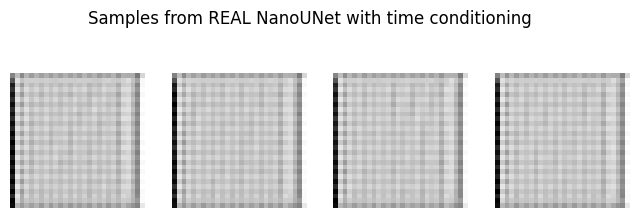

In [32]:
fig, axs = plt.subplots(1, 4, figsize=(8, 2))
fig.suptitle("Samples from REAL NanoUNet with time conditioning", y=1.15)
for i in range(4):
    axs[i].imshow(generated_images[i, :, :, 0], cmap='Greys')
    axs[i].axis('off')
plt.show()

------------------------------------------------------------------------------
## ***8. DEEP EXPORT WITH MULTIPLE INPUTS: MLIR, STABLEHLO***
------------------------------------------------------------------------------

In [33]:
print("\n--- Starting Multi-Format Export Pipeline ---")
export_dir = "./hf_real_export_package"
os.makedirs(export_dir, exist_ok=True)


--- Starting Multi-Format Export Pipeline ---


#### A pure function must now necessarily accept two arguments (x and amounts)

In [34]:
def forward_pure(state, x, amounts):
    reconstructed_model = nnx.merge(graphdef, state)
    return reconstructed_model(x, amounts)

In [35]:
sample_input_x = jnp.zeros((1, 28, 28, 1), dtype=jnp.float32)
sample_input_amount = jnp.zeros((1,), dtype=jnp.float32)

#### *A. Export to MLIR / StableHLO (JAX export supports multiple inputs as tuples)*

In [36]:
exported_module = jax.export.export(jax.jit(forward_pure))(model_state, sample_input_x, sample_input_amount)

In [37]:
with open(f"{export_dir}/nano_unet.mlir", "w") as f:
    f.write(exported_module.mlir_module())
    
print("➡️ MLIR file written with multiple input support.")

➡️ MLIR file written with multiple input support.


#### 1. Split the model into a static structure (graphdef) and pure JAX data (state)

In [38]:
print("📦 Breaking down Flax State into a flat list of pure JAX fields...")
graphdef, state = nnx.split(model)

📦 Breaking down Flax State into a flat list of pure JAX fields...


#### 2. 🔥 KEY STEP: We flatten the entire tree into a flat sheet of values and save its structure (treedef)

In [39]:
flat_leaves, treedef = jax.tree_util.tree_flatten(state)

#### 3. Extract the pure values (.value) from the parameters into a regular Python sheet
This step completely destroys the <class 'flax.nnx.variablelib.Param'> type.

In [40]:
pure_jax_leaves = [leaf.value if hasattr(leaf, 'value') else leaf for leaf in flat_leaves]

#### 4. The function will take as input this flat list of pure matrices

In [41]:
@jax.jit
def pure_forward(flat_leaves_input, x, amount):
    # Inside the function, we take those pure matrices, wrap them back into Param objects
    # and reconstruct the original Flax State using the saved tree definition (tree def)
    reconstructed_leaves = [nnx.Param(leaf) for leaf in flat_leaves_input]
    reconstructed_state = jax.tree_util.tree_unflatten(treedef, reconstructed_leaves)
    
    m = nnx.merge(graphdef, reconstructed_state)
    return m(x, amount)

#### 5. We call the exporter. The input is a plain Python list of pure fields, so JAX has nothing to complain about!

In [42]:
print("⚡ Exporting a pure JAX graph to StableHLO...")
exported_pure = jax.export.export(pure_forward)(pure_jax_leaves, sample_input_x, sample_input_amount)

⚡ Exporting a pure JAX graph to StableHLO...


#### 6. We call your function, which now finally works safely

In [43]:
print("💾 Saving an artifact using your function from JLNN...")
save_stablehlo_artifact(exported_pure, f"{export_dir}/nano_unet.stablehlo")

💾 Saving an artifact using your function from JLNN...
✓ StableHLO artifact saved to: ./hf_real_export_package/nano_unet.stablehlo
  Size: 7.75 KB
  Format: MLIR bytecode (StableHLO dialect)


----------------------------------------------------
## ***9. INDEPENDENT STABLEHLO RUNTIME VERIFICATION***
----------------------------------------------------

#### 1. We load binary data from disk

In [44]:
print("🔬 Loading and validating StableHLO model...")

with open(f"{export_dir}/nano_unet.stablehlo", "rb") as f:
    serialized_bytes = f.read()

🔬 Loading and validating StableHLO model...


#### 2. Deserialize back to a callable artifact (according to your docstring)

In [45]:
loaded_artifact = jax.export.deserialize(serialized_bytes)

#### 3. Compile into JIT for final hardware run

In [46]:
compiled_fn = jax.jit(loaded_artifact.call)

#### 4. Let's run the test

In [47]:
print("⚡ Hardware inference is running with the correct structure...")
stablehlo_output = compiled_fn(pure_jax_leaves, sample_input_x, sample_input_amount)

⚡ Hardware inference is running with the correct structure...


In [48]:
print(f"✅ Verification complete! Output shape: {stablehlo_output.shape}")

✅ Verification complete! Output shape: (1, 28, 28, 1)


#### 🖼️ View the result of the compiled StableHLO model

🎨 Plotting the denoised output from StableHLO...


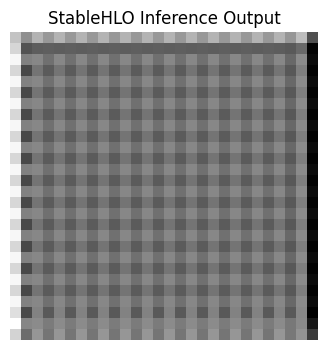

In [49]:
print("🎨 Plotting the denoised output from StableHLO...")

# Convert JAX Array to a regular numpy array for matplotlib
output_image = np.array(stablehlo_output)

# Remove the batch (1) and channel (1) dimensions to leave a clean 28x28 square
output_image = np.squeeze(output_image)

plt.figure(figsize=(4, 4))
plt.imshow(output_image, cmap="gray")
plt.title("StableHLO Inference Output")
plt.axis("off")
plt.show()

#### 5. Wrapping the checkpoint and sending it to the Hugging Face Hub (same as in the previous template)

In [50]:
shutil.copytree(checkpoint_dir, f"{export_dir}/jax_checkpoint", dirs_exist_ok=True)

'./hf_real_export_package/jax_checkpoint'

In [51]:
print(f"📦 All real NanoUNet formats are ready to be sent in the {export_dir} folder")

📦 All real NanoUNet formats are ready to be sent in the ./hf_real_export_package folder


------------------------------------------------------------------------------
## ***10. PUBLISHING TO THE HUGGING FACE HUB (with an auto-generated Model Card)***
------------------------------------------------------------------------------

In [52]:
# 🔧 Fill in your own namespace/repo name before running the upload cells.
HF_REPO_ID = "KRadim/nano-unet-diffusion-mnist"  
PUSH_TO_HUB = not DEBUG  # avoid accidentally spamming the Hub with throwaway debug runs

#### Authenticating with the Hugging Face Hub

In [53]:
if PUSH_TO_HUB:
    if hf_token:
        hf_login(token=hf_token)
    else:
        hf_login()  # interactive token prompt
else:
    print("ℹ️ PUSH_TO_HUB is False - skipping Hub authentication.")

#### Generating the Model Card (README.md) with metadata

In [54]:
card_data = ModelCardData(
    language="en",
    license="mit",
    library_name="jax",
    tags=["diffusion-model", "flax", "flax-nnx", "jax", "unet", "mnist", "image-generation", "from-scratch"],
    datasets=["mnist"],
    pipeline_tag="unconditional-image-generation",
)

training_data_desc = "1200 debug samples (2% subset)" if DEBUG else "full 60,000-image training set"

model_card_text = f"""

# NanoUNet Diffusion Model (Flax NNX, JAX)

A tiny, from-scratch DDPM-style diffusion model trained on MNIST, built with **JAX** and **Flax NNX**.
The model is a small conditional U-Net (`RealNanoUNet`) that predicts the clean image from a noisy
input, conditioned on a sinusoidally embedded noise level.

## Model Details

- **Architecture:** 2-level U-Net (strided-conv downsampling, transposed-conv upsampling, one skip connection)
- **Conditioning:** scalar noise level `amount ∈ [0, 1]`, embedded with sinusoidal positional embeddings
- **Framework:** JAX / Flax NNX
- **Training data:** MNIST — {{training_data_desc}}
- **Optimizer:** AdamW with warmup-cosine-decay LR schedule, gradient clipping (global norm 1.0)
- **Epochs:** {NUM_EPOCHS}
- **Batch size:** {BATCH_SIZE}

## Exported Formats

This repository bundles multiple export formats of the same trained weights:

| File / Folder | Format | Notes |
|---|---|---|
| `model_checkpoint/` | Orbax checkpoint | Native JAX/Flax NNX state, load with `orbax.checkpoint` |
| `nano_unet.mlir` | MLIR | StableHLO dialect, via `jax.export` |
| `nano_unet.stablehlo` | StableHLO bytecode | Portable compiled representation (FlatBuffer binary with baked weights) |


## Usage (JAX / Flax NNX Native)

```python
import orbax.checkpoint as ocp
from flax import nnx

# Recreate the model skeleton, then restore the trained parameters
model = RealNanoUNet(in_features=1, out_features=1, rngs=nnx.Rngs(0))
graphdef, abstract_state = nnx.split(model)

checkpointer = ocp.Checkpointer(ocp.StandardCheckpointHandler())

state = checkpointer.restore("model_checkpoint", abstract_state)
model = nnx.merge(graphdef, state)
```
## ⚡ How to use the StableHLO Model (Production Inference)

The ultimate advantage of this pipeline is that you **don't need the `RealNanoUNet` Python architecture class anymore** to deploy it. Because the weights are decoupled from Flax NNX structures to prevent serialization conflicts, the function signature expects the flat weight parameters as its first argument, followed by the inference data.

Here is how to properly load and execute the pre-compiled StableHLO graph using pure JAX:

```python
import jax
import numpy as np

# 1. Load the pre-compiled StableHLO bytecode from file
with open("nano_unet.stablehlo", "rb") as f:
    stablehlo_bytecode = f.read()

# 2. Deserialize it back into a callable JAX artifact
loaded_artifact = jax.export.deserialize(stablehlo_bytecode)
compiled_fn = jax.jit(loaded_artifact.call)

# 3. Reconstruct or pass the raw weights tree/list matching the export structure.
# (If using standard JAX deployment, you can extract weights from the checkpoint as a pure list of arrays)
# pure_jax_leaves = [...] 

# 4. Prepare raw data inputs
sample_input_x = np.random.randn(1, 28, 28, 1).astype(np.float32)
sample_input_amount = np.array([0.5], dtype=np.float32)

# 5. Run lightning-fast hardware inference
# 🔥 IMPORTANT SIGNATURE: Weights list must be provided as the first argument!
output = compiled_fn(pure_jax_leaves, sample_input_x, sample_input_amount)
print("StableHLO Output shape:", output.shape)
```

## Technical Parameters & Design Choices

- **Architecture:** A fully functional, conditioned Convolutional U-Net tailored for efficient edge inference and educational deployment.
- **Noise Process:** Uses continuous linear interpolation between data and noise space for faster convergence and streamlined math, making it highly transparent for training.
- **Scale:** The network scale and hyperparameter configuration are intentionally optimized to allow rapid training and instant multi-platform deployment (StableHLO/MLIR) without requiring enterprise-grade cluster resources.

"""

card = ModelCard(model_card_text, ignore_metadata_errors=True)
card.data = card_data
card.save(f"{export_dir}/README.md")
print(f"📝 Model card written to {export_dir}/README.md")

Repo card metadata block was not found. Setting CardData to empty.


📝 Model card written to ./hf_real_export_package/README.md


#### Creating the repo and pushing everything (checkpoint + MLIR/StableHLO + model card) to the Hub

In [55]:
if PUSH_TO_HUB:
    # 1. Paths to your folders on Kagglu (as shown in the image)
    checkpoint_src = "/kaggle/working/real_nano_unet_checkpoint"
    checkpoint_dst = os.path.join(export_dir, "model_checkpoint")
    
    # 2. 🔥 If the checkpoint is not yet in the export folder, we will copy it there
    if os.path.exists(checkpoint_src) and not os.path.exists(checkpoint_dst):
        print("📦 Copying Orbax checkpoint to export package...")
        shutil.copytree(checkpoint_src, checkpoint_dst)
    
    print(f"🤗 Connecting to Hugging Face Hub and creating repository {HF_REPO_ID}...")
    api = HfApi()
    api.create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)
    
    commit_msg = "Upload NanoUNet model (Orbax checkpoint + native MLIR + compiled StableHLO artifact)"
    
    print(f"🚀 Sending COMPLETE package (models + checkpoint) from '{export_dir}'...")
    # Now the export_dir folder contains both the model files and the 'model_checkpoint' folder
    api.upload_folder(
        repo_id=HF_REPO_ID,
        folder_path=export_dir,
        repo_type="model",
        commit_message=commit_msg,
    )
    print(f"🎉 Done! Everything (scales and compiled models) is live at: https://huggingface.co/{HF_REPO_ID}")
else:
    print("ℹ️ PUSH_TO_HUB is False (DEBUG run) - skipping upload.")

📦 Copying Orbax checkpoint to export package...
🤗 Connecting to Hugging Face Hub and creating repository KRadim/nano-unet-diffusion-mnist...
🚀 Sending COMPLETE package (models + checkpoint) from './hf_real_export_package'...
🎉 Done! Everything (scales and compiled models) is live at: https://huggingface.co/KRadim/nano-unet-diffusion-mnist
